# 10 — Overlay results on a real OpenStreetMap basemap

Notebook 06 showed how to turn an analysis grid into a PNG. This one
goes one step further: it places that result image **on top of a real,
interactive OpenStreetMap** so the heatmap sits in geographic context.

The trick is `AreaResult.bounds` — the geographic extent of the merged
grid as `(min_lng, min_lat, max_lng, max_lat)`. We render the grid to a
transparent RGBA image and hand it, plus those bounds, to
[`folium`](https://python-visualization.github.io/folium/)'s
`ImageOverlay`. No reprojection math required — folium speaks lat/lon
directly.

> `folium` is not a hard SDK dependency. Install it for this notebook:
> `pip install folium` (it's also in `requirements.txt`).

In [5]:
from dotenv import load_dotenv

load_dotenv()

import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image
import folium

from infrared_sdk import InfraredClient
from infrared_sdk.analyses.types import AnalysesName, WindModelRequest
from cities import get

OUTPUT_DIR = os.path.join(".", "_outputs_10")
os.makedirs(OUTPUT_DIR, exist_ok=True)

city = get("munich")
print(f"City: {city.name}  ({city.latitude}, {city.longitude})")

City: Munich  (48.1374, 11.5755)


## 1. Run the analysis over a larger, irregular area

We use `city.polygon_large` — an irregular ~1.2 km polygon that spans
several server-side tiles — so the overlay covers real city blocks
rather than a single square. Drop to `city.polygon_small` (or switch
city via `get("tokyo")`) for a quick, single-tile run.

In [6]:
with InfraredClient() as client:
    area = client.buildings.get_area(city.polygon_large)
    [result] = client.run_area_and_wait(
        [
            WindModelRequest(
                analysis_type=AnalysesName.wind_speed,
                wind_speed=5,
                wind_direction=270,
            )
        ],
        city.polygon_large,
        buildings=area.buildings,
    )

min_lng, min_lat, max_lng, max_lat = result.bounds
print(f"analysis    : {result.analysis_type}")
print(f"buildings   : {area.total_buildings}")
print(f"tiles        : {result.succeeded_jobs}/{result.total_jobs} succeeded")
print(f"grid_shape  : {result.grid_shape}")
print(
    f"bounds      : lng [{min_lng:.5f}, {max_lng:.5f}]  lat [{min_lat:.5f}, {max_lat:.5f}]"
)

[INFO] [SDK:BigPayload] route=inline url=https://api-test.infrared.city/buildings raw_bytes=187 threshold=5242880 enabled=True
[INFO] [SDK:BigPayload] route=inline url=https://api-test.infrared.city/buildings raw_bytes=187 threshold=5242880 enabled=True
[INFO] [SDK:BigPayload] route=inline url=https://api-test.infrared.city/buildings raw_bytes=187 threshold=5242880 enabled=True
[INFO] [SDK:BigPayload] route=inline url=https://api-test.infrared.city/buildings raw_bytes=187 threshold=5242880 enabled=True
[INFO] [SDK:BigPayload] route=inline url=https://api-test.infrared.city/buildings raw_bytes=186 threshold=5242880 enabled=True
[INFO] [SDK:BigPayload] route=inline url=https://api-test.infrared.city/buildings raw_bytes=188 threshold=5242880 enabled=True
[INFO] [SDK:BigPayload] route=inline url=https://api-test.infrared.city/buildings raw_bytes=188 threshold=5242880 enabled=True
[INFO] [SDK:BigPayload] route=inline url=https://api-test.infrared.city/buildings raw_bytes=188 threshold=52428

## 2. Render the grid to a *transparent* PNG

Two things matter for a clean overlay:

1. **Don't crop.** `result.bounds` describes the **full** merged grid,
   so the image must correspond to it cell-for-cell. The polygon is
   irregular, so every cell outside it (and any tile gaps) is `NaN`; we
   render those fully transparent, letting the map show through and
   giving the overlay the polygon's true shape.
2. **North-up.** Row 0 of `merged_grid` is the *south* edge. folium's
   `ImageOverlay` draws the image's first row at the *north* edge of the
   bounds, so we `np.flipud` first.

We colour with a matplotlib colormap whose "bad" (NaN) colour is
transparent. For Infrared's exact canonical palette instead, render the
PNG server-side with `client.weather.gen_grid_image(...)` — see
notebook 06.

rendered 1280x1280 RGBA PNG


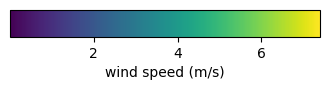

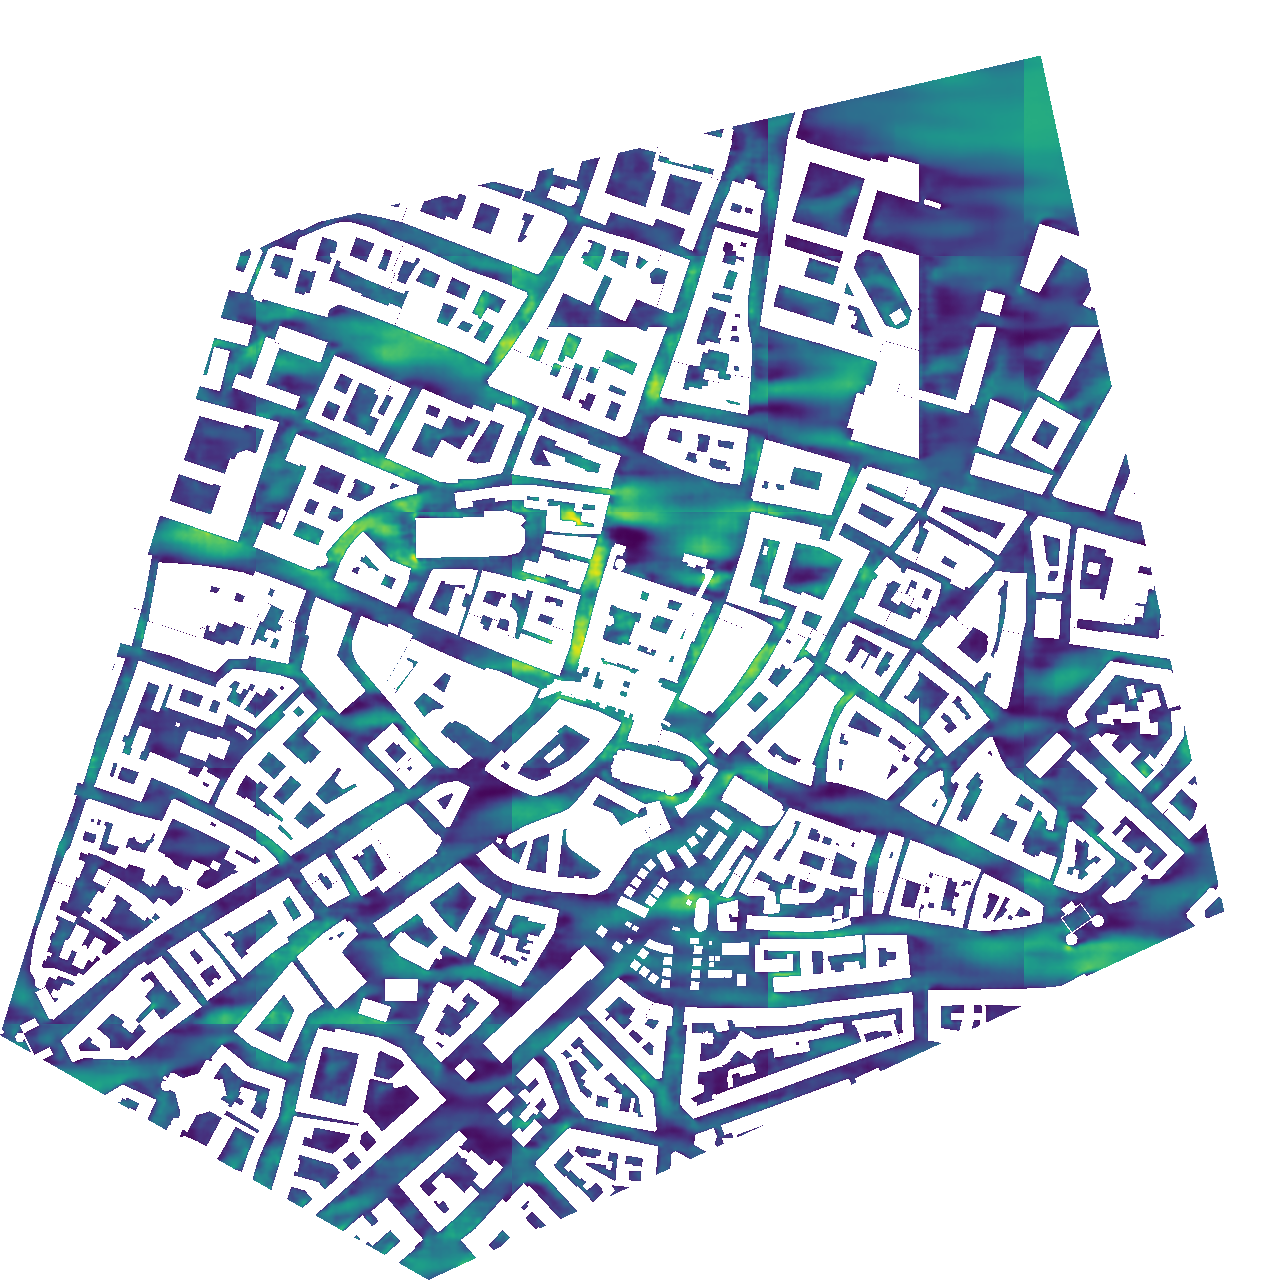

In [7]:
# Full grid, north-up. Do NOT crop — bounds covers the whole grid.
arr = np.flipud(result.merged_grid)
masked = np.ma.masked_invalid(arr)

valid = masked.compressed()
norm = mcolors.Normalize(vmin=float(valid.min()), vmax=float(valid.max()))

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad(alpha=0.0)  # NaN / outside-polygon -> fully transparent

rgba = (cmap(norm(masked)) * 255).astype(np.uint8)  # H x W x 4
img = Image.fromarray(rgba, mode="RGBA")

print(f"rendered {img.width}x{img.height} RGBA PNG")

# A small colourbar so the overlay has a readable scale.
fig, cax = plt.subplots(figsize=(4, 0.35))
fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cax,
    orientation="horizontal",
    label="wind speed (m/s)",
)
plt.show()
img

## 3. Overlay on an interactive OpenStreetMap

`ImageOverlay` takes the image plus `[[min_lat, min_lng], [max_lat,
max_lng]]` bounds. Drag, zoom, and toggle the layer to compare the
analysis against the real streets and buildings underneath.

saved interactive map -> .\_outputs_10\wind_map_overlay.html



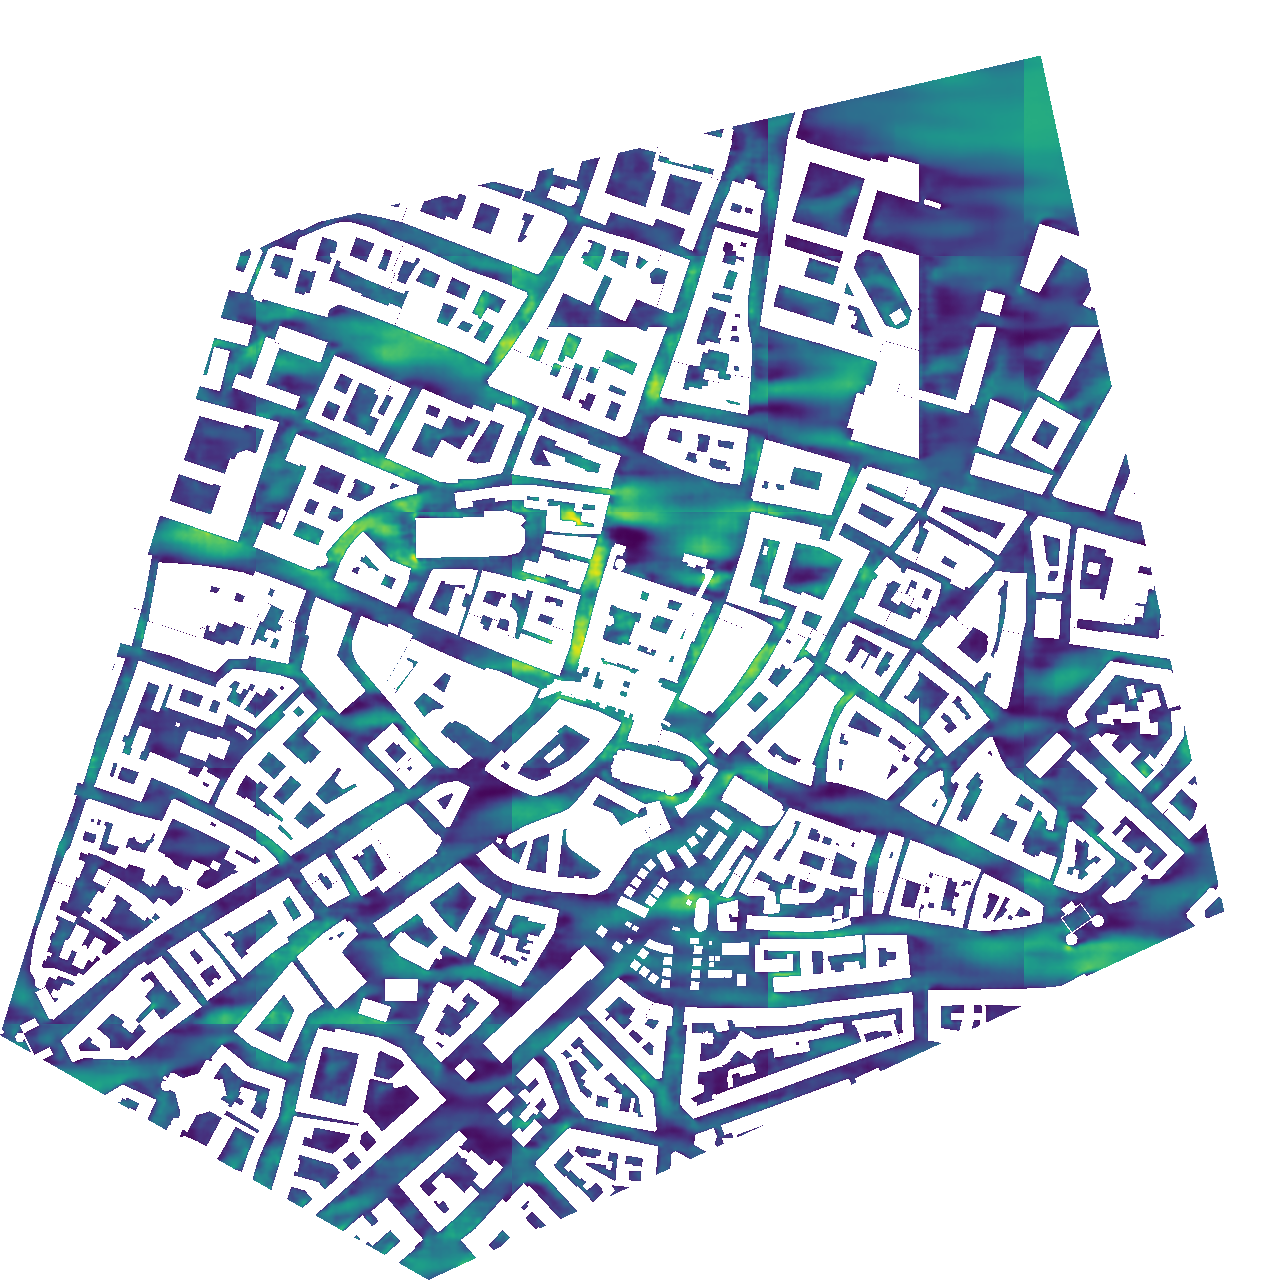

In [8]:
m = folium.Map(tiles="OpenStreetMap")

folium.raster_layers.ImageOverlay(
    image=np.asarray(img),
    bounds=[[min_lat, min_lng], [max_lat, max_lng]],
    opacity=0.75,
    name=f"{result.analysis_type}",
).add_to(m)

folium.LayerControl().add_to(m)

# Frame the map to the analysis extent (works for any polygon size).
m.fit_bounds([[min_lat, min_lng], [max_lat, max_lng]])

out_html = os.path.join(OUTPUT_DIR, "wind_map_overlay.html")
m.save(out_html)
print(f"saved interactive map -> {out_html}")
m

## Notes

- **Opacity.** Tune the `opacity=` argument (0–1) to see more of the map
  or more of the analysis.
- **Polygon size.** This runs `city.polygon_large` (several tiles). Use
  `city.polygon_small` for a fast single-tile run — the overlay code is
  unchanged because `bounds` always reports the true (padded) grid
  extent and `fit_bounds` reframes the map automatically.
- **Canonical colours.** This notebook colours locally so NaN can be
  transparent. For the platform's exact palette, fetch the PNG from
  `client.weather.gen_grid_image(...)` (notebook 06) and apply the grid's
  NaN mask as an alpha channel before handing it to `ImageOverlay`.
- **Coverage caveat.** Infrared's gridded layers come from
  OpenStreetMap-style sources worldwide, but density and freshness vary
  by region. If a fetch returns zero buildings, try another polygon or
  city.